In [3]:
!pip install snntorch

In [ ]:
import snntorch
print(snntorch.__version__)

1.0.0


In [4]:


import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import snntorch as snn
from snntorch import functional as SF
import numpy as np
import os

# ── Parameters (match these to your Verilog parameters) ──────────────────────
BETA        = 0.5     # leak factor — same as α in your LIF (>>>1 = 0.5)
N_STEPS     = 25      # number of timesteps per sample (spike window)
BITWIDTH    = 16      # must match BITWIDTH in lif.v
BATCH_SIZE  = 128
EPOCHS      = 5
LR          = 1e-3
HIDDEN      = 128     # neurons in hidden layer
OUTPUT      = 10      # digits 0-9

# ── Dataset ───────────────────────────────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root="data", train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

# ── Model ─────────────────────────────────────────────────────────────────────
# Two linear layers with LIF neurons after each
net = nn.Sequential(
    nn.Linear(784, HIDDEN, bias=False),   # W1: weight lookup when spike=1
    snn.Leaky(beta=BETA, init_hidden=True),
    nn.Linear(HIDDEN, OUTPUT, bias=False), # W2
    snn.Leaky(beta=BETA, init_hidden=True, output=True)
)

optimizer = torch.optim.Adam(net.parameters(), lr=LR)
loss_fn   = SF.ce_rate_loss()   # cross-entropy on spike rate

# Rate coding method
def rate_encode(imgs, n_steps):
    """
    imgs: [batch, 784] float tensor, values 0.0 to 1.0
    Returns: [n_steps, batch, 784] binary spike tensor
    """
    spikes = []
    for _ in range(n_steps):
        # each pixel fires with probability = pixel intensity
        spike = torch.bernoulli(imgs)   # 1 with prob=pixel, 0 otherwise
        spikes.append(spike)
    return torch.stack(spikes, dim=0)  # [T, B, 784]


# ── Training ──────────────────────────────────────────────────────────────────
def train_one_epoch(loader):
    net.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs = imgs.view(imgs.size(0), -1)  # [B, 784]

        # reset membrane potentials
        for m in net.modules():
            if hasattr(m, 'reset_hidden'):
                m.reset_hidden()

        # rate encode: pixels → spike trains
        spike_input = rate_encode(imgs, N_STEPS)  # [T, B, 784]

        spk_rec = []
        for t in range(N_STEPS):
            spk_out, _ = net(spike_input[t])   # feed one timestep of spikes
            spk_rec.append(spk_out)

        spk_rec = torch.stack(spk_rec, dim=0)
        loss = loss_fn(spk_rec, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(loader):
    net.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.view(imgs.size(0), -1)
            for m in net.modules():
              if hasattr(m, 'reset_hidden'):
                m.reset_hidden()
            spk_rec = []
            for _ in range(N_STEPS):
                spk_out, _ = net(imgs)
                spk_rec.append(spk_out)
            spk_rec  = torch.stack(spk_rec, dim=0)  # [T, B, 10]
            pred     = spk_rec.sum(0).argmax(1)      # most spikes = prediction
            correct += (pred == labels).sum().item()
            total   += labels.size(0)
    return 100 * correct / total

print("Training SNN on MNIST...")
for epoch in range(EPOCHS):
    loss = train_one_epoch(train_loader)
    acc  = evaluate(test_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={loss:.4f}  test_acc={acc:.2f}%")

# ── Weight extraction ─────────────────────────────────────────────────────────
# Get the two weight matrices
layers = [m for m in net.modules() if isinstance(m, nn.Linear)]
W1 = layers[0].weight.detach().numpy()   # shape: (128, 784)
W2 = layers[1].weight.detach().numpy()   # shape: (10, 128)

print(f"\nW1 shape: {W1.shape}  min={W1.min():.3f}  max={W1.max():.3f}")
print(f"W2 shape: {W2.shape}  min={W2.min():.3f}  max={W2.max():.3f}")

# ── Quantization: float → signed 16-bit fixed point ──────────────────────────
# Scale so that the largest weight fills ~half the signed range (leave headroom)
SCALE = (2**(BITWIDTH-1) - 1) / (2 * max(np.abs(W1).max(), np.abs(W2).max()))

W1_q = np.clip(np.round(W1 * SCALE), -(2**(BITWIDTH-1)), (2**(BITWIDTH-1))-1).astype(np.int16)
W2_q = np.clip(np.round(W2 * SCALE), -(2**(BITWIDTH-1)), (2**(BITWIDTH-1))-1).astype(np.int16)

print(f"\nQuantization scale: {SCALE:.4f}")
print(f"W1_q  min={W1_q.min()}  max={W1_q.max()}")
print(f"W2_q  min={W2_q.min()}  max={W2_q.max()}")

# ── Save as .npy (Python golden model uses this) ──────────────────────────────
os.makedirs("weights", exist_ok=True)
np.save("weights/W1_q.npy", W1_q)
np.save("weights/W2_q.npy", W2_q)
print("\nSaved: weights/W1_q.npy  weights/W2_q.npy")

# ── Save as .mem (Verilog $readmemh loads this into BRAM) ─────────────────────
def save_mem(weights, filename):
    """Save weight matrix as hex .mem file, row by row."""
    with open(filename, "w") as f:
        for row in weights:
            for val in row:
                # convert signed int16 to unsigned hex (two's complement)
                hex_val = format(int(val) & 0xFFFF, "04X")
                f.write(hex_val + "\n")
    print(f"Saved: {filename}")

save_mem(W1_q, "weights/W1.mem")
save_mem(W2_q, "weights/W2.mem")

print("\nDone. In your Verilog testbench, load weights like this:")
print('  $readmemh("weights/W1.mem", weight_bram_layer1);')
print('  $readmemh("weights/W2.mem", weight_bram_layer2);')


100%|██████████| 9.91M/9.91M [00:00<00:00, 140MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 37.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 102MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.73MB/s]


Training SNN on MNIST...
Epoch 1/5  loss=1.6176  test_acc=92.53%
Epoch 2/5  loss=1.5317  test_acc=93.87%
Epoch 3/5  loss=1.5173  test_acc=94.44%
Epoch 4/5  loss=1.5090  test_acc=94.97%
Epoch 5/5  loss=1.5033  test_acc=95.47%

W1 shape: (128, 784)  min=-0.539  max=0.556
W2 shape: (10, 128)  min=-0.929  max=0.534

Quantization scale: 17637.1074
W1_q  min=-9507  max=9803
W2_q  min=-16383  max=9424

Saved: weights/W1_q.npy  weights/W2_q.npy
Saved: weights/W1.mem
Saved: weights/W2.mem

Done. In your Verilog testbench, load weights like this:
  $readmemh("weights/W1.mem", weight_bram_layer1);
  $readmemh("weights/W2.mem", weight_bram_layer2);


**Identifying the threshold value to be used in verilog**

In [ ]:
# ── Threshold for Verilog ─────────────────────────────────────
threshold_float = 1.0   # snnTorch default threshold
threshold_verilog = int(round(threshold_float * SCALE))
print(f"\nVerilog THRESHOLD = {threshold_verilog}")


Verilog THRESHOLD = 17774


### Modified Model Architecture for Improved Accuracy

This section demonstrates how to modify the SNN architecture to potentially improve accuracy by increasing its depth and adding a dropout layer. You can further experiment with `HIDDEN_1`, `HIDDEN_2`, and the `dropout_rate`.

**Note:** After making these changes, you would need to re-run the training and evaluation cells.

In [1]:


import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import snntorch as snn
from snntorch import functional as SF
import numpy as np
import os

# ── Parameters (match these to your Verilog parameters) ──────────────────────
BETA        = 0.5     # leak factor — same as α in your LIF (>>>1 = 0.5)
N_STEPS     = 25      # number of timesteps per sample (spike window)
BITWIDTH    = 16      # must match BITWIDTH in lif.v
BATCH_SIZE  = 128
EPOCHS      = 5
LR          = 1e-3
HIDDEN_1 = 256 # Increased size for first hidden layer
HIDDEN_2 = 128 # New second hidden layer
DROPOUT_RATE = 0.5 # Example dropout rate
OUTPUT      = 10      # digits 0-9

# ── Dataset ───────────────────────────────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root="data", train=True,  download=True, transform=transform) #loading the training data(60000)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=transform) #loading the testing data(10000)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

# ── Model ─────────────────────────────────────────────────────────────────────
# Two linear layers with LIF neurons after each
net = nn.Sequential(
    nn.Linear(784, HIDDEN_1, bias=False),
    snn.Leaky(beta=BETA, init_hidden=True),
    nn.Dropout(p=DROPOUT_RATE), # Add dropout after the first spiking layer
    nn.Linear(HIDDEN_1, HIDDEN_2, bias=False), # New hidden layer
    snn.Leaky(beta=BETA, init_hidden=True),
    nn.Linear(HIDDEN_2, OUTPUT, bias=False),
    snn.Leaky(beta=BETA, init_hidden=True, output=True)
)



optimizer = torch.optim.Adam(net.parameters(), lr=LR)
loss_fn   = SF.ce_rate_loss()   # cross-entropy on spike rate

# Rate coding method
def rate_encode(imgs, n_steps):
    """
    imgs: [batch, 784] float tensor, values 0.0 to 1.0
    Returns: [n_steps, batch, 784] binary spike tensor
    """
    spikes = []
    for _ in range(n_steps):
        # each pixel fires with probability = pixel intensity
        spike = torch.bernoulli(imgs)   # 1 with prob=pixel, 0 otherwise
        spikes.append(spike)
    return torch.stack(spikes, dim=0)  # [T, B, 784]


# ── Training ──────────────────────────────────────────────────────────────────
def train_one_epoch(loader):
    net.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs = imgs.view(imgs.size(0), -1)  # [B, 784]

        # reset membrane potentials
        for m in net.modules():
            if hasattr(m, 'reset_hidden'):
                m.reset_hidden()

        # rate encode: pixels → spike trains
        spike_input = rate_encode(imgs, N_STEPS)  # [T, B, 784]

        spk_rec = []
        for t in range(N_STEPS):
            spk_out, _ = net(spike_input[t])   # feed one timestep of spikes
            spk_rec.append(spk_out)

        spk_rec = torch.stack(spk_rec, dim=0)
        loss = loss_fn(spk_rec, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(loader):
    net.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.view(imgs.size(0), -1)

            # --- FIX 1: Apply rate coding to generate spike trains ---
            spike_input = rate_encode(imgs, N_STEPS)  # Shape: [T, B, 784]

            for m in net.modules():
                if hasattr(m, 'reset_hidden'):
                    m.reset_hidden()

            spk_rec = []
            # --- FIX 2: Iterate over time 't' and pass spikes, not raw imgs ---
            for t in range(N_STEPS):
                spk_out, _ = net(spike_input[t])
                spk_rec.append(spk_out)

            spk_rec  = torch.stack(spk_rec, dim=0)   # Shape: [T, B, 10]
            pred     = spk_rec.sum(0).argmax(1)      # most spikes = prediction
            correct += (pred == labels).sum().item()
            total   += labels.size(0)

    return 100 * correct / total

print("Training SNN on MNIST...")
for epoch in range(EPOCHS):
    loss = train_one_epoch(train_loader)
    acc  = evaluate(test_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={loss:.4f}  test_acc={acc:.2f}%")

# ── Weight extraction ─────────────────────────────────────────────────────────
# Get the two weight matrices
layers = [m for m in net.modules() if isinstance(m, nn.Linear)]
W1 = layers[0].weight.detach().numpy()   # shape: (128, 784)
W2 = layers[1].weight.detach().numpy()   # shape: (10, 128)

print(f"\nW1 shape: {W1.shape}  min={W1.min():.3f}  max={W1.max():.3f}")
print(f"W2 shape: {W2.shape}  min={W2.min():.3f}  max={W2.max():.3f}")

# ── Quantization: float → signed 16-bit fixed point ──────────────────────────
# Scale so that the largest weight fills ~half the signed range (leave headroom)
SCALE = (2**(BITWIDTH-1) - 1) / (2 * max(np.abs(W1).max(), np.abs(W2).max()))

W1_q = np.clip(np.round(W1 * SCALE), -(2**(BITWIDTH-1)), (2**(BITWIDTH-1))-1).astype(np.int16)
W2_q = np.clip(np.round(W2 * SCALE), -(2**(BITWIDTH-1)), (2**(BITWIDTH-1))-1).astype(np.int16)

print(f"\nQuantization scale: {SCALE:.4f}")
print(f"W1_q  min={W1_q.min()}  max={W1_q.max()}")
print(f"W2_q  min={W2_q.min()}  max={W2_q.max()}")

# ── Save as .npy (Python golden model uses this) ──────────────────────────────
os.makedirs("weights", exist_ok=True)
np.save("weights/W1_q.npy", W1_q)
np.save("weights/W2_q.npy", W2_q)
print("\nSaved: weights/W1_q.npy  weights/W2_q.npy")

# ── Save as .mem (Verilog $readmemh loads this into BRAM) ─────────────────────
def save_mem(weights, filename):
    """Save weight matrix as hex .mem file, row by row."""
    with open(filename, "w") as f:
        for row in weights:
            for val in row:
                # convert signed int16 to unsigned hex (two's complement)
                hex_val = format(int(val) & 0xFFFF, "04X")
                f.write(hex_val + "\n")
    print(f"Saved: {filename}")

save_mem(W1_q, "weights/W1.mem")
save_mem(W2_q, "weights/W2.mem")

print("\nDone. In your Verilog testbench, load weights like this:")
print('  $readmemh("weights/W1.mem", weight_bram_layer1);')
print('  $readmemh("weights/W2.mem", weight_bram_layer2);')


ModuleNotFoundError: No module named 'snntorch'

In [ ]:
from google.colab import files
files.download("weights/W1.mem")
files.download("weights/W2.mem")
files.download("weights/W1_q.npy")
files.download("weights/W2_q.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**GENERATING THE SPIKES OF THE IMAGE BEFORE SENDING IT TO VERILOG**

In [ ]:
# ── Export one test image as spike trains ─────────────────────
from torchvision import datasets, transforms

# grab first test image
test_data  = datasets.MNIST(root="data", train=False, download=True,
                             transform=transforms.ToTensor())
img, label = test_data[0]
img_flat   = img.view(-1)          # 784 floats, 0.0–1.0

print(f"True label: {label}")

# rate encode — same as training
torch.manual_seed(42)              # fixed seed = reproducible spikes
spike_trains = rate_encode(img_flat.unsqueeze(0), N_STEPS)  # [25, 1, 784]

# save each timestep as a .mem file
os.makedirs("weights/spikes", exist_ok=True)
for t in range(N_STEPS):
    spk = spike_trains[t, 0].numpy().astype(int)  # 784 bits

    # pack 784 bits into 98 bytes (784/8 = 98), save as hex
    # but for simplicity save as one hex word per 32 bits
    # easiest: save as 784 individual lines of 0 or 1
    with open(f"weights/spikes/spike_t{t:02d}.mem", "w") as f:
        # pack into 32-bit words (784 bits = 24 words + 16 bits)
        # pad to 800 bits (25 words of 32 bits)
        padded = np.zeros(800, dtype=int)
        padded[:784] = spk
        for w in range(25):
            word = 0
            for b in range(32):
                word |= (int(padded[w*32 + b]) << b)
            f.write(f"{word:08X}\n")

print("Saved spike files to weights/spikes/")
print(f"Feed these to Verilog in order: spike_t00.mem → spike_t24.mem")
print(f"Expected output class: {label}")

True label: 7
Saved spike files to weights/spikes/
Feed these to Verilog in order: spike_t00.mem → spike_t24.mem
Expected output class: 7


In [ ]:
import shutil
from google.colab import files

# Compress the entire spikes directory into a zip file
shutil.make_archive('all_spikes', 'zip', 'weights/spikes')

# Download the single zip file
files.download('all_spikes.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**snn_integer_inference.py**

In [5]:
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── 1. Configuration & Hardware Parameters ────────────────────────────────────
N_STEPS = 25
BATCH_SIZE = 128
SCALE = 17637.1074  # SCALE printed in previous script
THRESHOLD = int(1.0 * SCALE) # The scaled digital firing threshold

# ── 2. Load the Dataset & Quantized Weights ───────────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])
test_data = datasets.MNIST(root="data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# Load the 16-bit integer weights you saved earlier
W1_q = np.load("weights/W1_q.npy").astype(np.int32)  # (128, 784)
W2_q = np.load("weights/W2_q.npy").astype(np.int32)  # (10, 128)

# ── 3. The Hardware-Accurate LIF Neuron ───────────────────────────────────────
class DigitalLIFNeuron:
    def __init__(self, num_neurons, batch_size):
        # The V_mem register, initialized to 0
        self.v_mem = np.zeros((batch_size, num_neurons), dtype=np.int32)

    def step(self, input_current):
        """Simulates one clock cycle of the neuron"""
        # 1. Leak: Right shift by 1 (equivalent to beta = 0.5)
        # Using np.right_shift handles the sign bit correctly for two's complement
        self.v_mem = np.right_shift(self.v_mem, 1)

        # 2. Integrate: Add the incoming integer current (weights)
        self.v_mem += input_current

        # 3. Fire: Check against the integer threshold
        spikes_out = (self.v_mem >= THRESHOLD).astype(np.int32)

        # 4. Reset: Hard reset to 0 if a spike occurred
        # In hardware, this is a multiplexer controlled by the spike output
        self.v_mem = np.where(spikes_out == 1, 0, self.v_mem)

        return spikes_out

    def reset(self):
        """Clears the register between images"""
        self.v_mem.fill(0)

# ── 4. Spiking Rate Encoder (NumPy Version) ───────────────────────────────────
def rate_encode_numpy(imgs, n_steps):
    """Converts continuous [0.0, 1.0] pixels to discrete binary spikes"""
    batch_size = imgs.shape[0]
    spikes = np.zeros((n_steps, batch_size, 784), dtype=np.int32)
    for t in range(n_steps):
        # Generate random values to compare against pixel intensity
        rand_vals = np.random.rand(batch_size, 784)
        spikes[t] = (rand_vals < imgs).astype(np.int32)
    return spikes

# ── 5. The Inference Loop (Simulating Clock Cycles) ───────────────────────────
def run_hardware_simulation():
    layer1 = DigitalLIFNeuron(num_neurons=128, batch_size=BATCH_SIZE)
    layer2 = DigitalLIFNeuron(num_neurons=10,  batch_size=BATCH_SIZE)

    correct = 0
    total = 0

    print("Starting bit-accurate integer simulation...")

    for imgs, labels in test_loader:
        # Handle the last batch if it's smaller than BATCH_SIZE
        current_batch_size = imgs.size(0)
        if current_batch_size != BATCH_SIZE:
            layer1 = DigitalLIFNeuron(num_neurons=128, batch_size=current_batch_size)
            layer2 = DigitalLIFNeuron(num_neurons=10,  batch_size=current_batch_size)

        imgs_np = imgs.view(current_batch_size, -1).numpy()
        labels_np = labels.numpy()

        # Generate input spikes
        spike_input = rate_encode_numpy(imgs_np, N_STEPS)

        # Reset memory registers for the new image
        layer1.reset()
        layer2.reset()

        output_spikes_record = np.zeros((N_STEPS, current_batch_size, 10), dtype=np.int32)

        # Simulating time-steps (Clock Cycles)
        for t in range(N_STEPS):
            # Layer 1 Dataflow: Spikes(0 or 1) matrix-multiplied by integer weights
            # In hardware, this is an accumulation tree checking if input spike is 1
            current_l1 = np.dot(spike_input[t], W1_q.T)
            spikes_l1 = layer1.step(current_l1)

            # Layer 2 Dataflow
            current_l2 = np.dot(spikes_l1, W2_q.T)
            spikes_l2 = layer2.step(current_l2)

            output_spikes_record[t] = spikes_l2

        # Tally the spikes. The neuron with the most spikes is the prediction.
        total_spikes_per_class = output_spikes_record.sum(axis=0)
        predictions = total_spikes_per_class.argmax(axis=1)

        correct += np.sum(predictions == labels_np)
        total += current_batch_size

    accuracy = 100 * correct / total
    print(f"Hardware Simulation Accuracy: {accuracy:.2f}%")

if __name__ == "__main__":
    run_hardware_simulation()

Starting bit-accurate integer simulation...
Hardware Simulation Accuracy: 95.55%


─── SNN Hardware Inference Result ───
Actual Label:   9
SNN Prediction: 9
-------------------------------------
Spikes fired per output neuron:
 Neuron 0:  0 spikes 
 Neuron 1:  0 spikes 
 Neuron 2:  0 spikes 
 Neuron 3:  0 spikes 
 Neuron 4:  0 spikes 
 Neuron 5:  0 spikes 
 Neuron 6:  0 spikes 
 Neuron 7:  0 spikes 
 Neuron 8:  0 spikes 
 Neuron 9: 25 spikes  <--- WINNER!


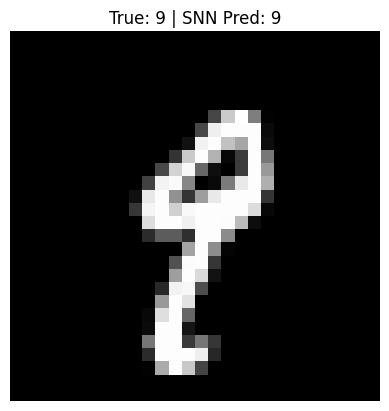

In [15]:
import matplotlib.pyplot as plt
import random

def test_single_image():
    # 1. Get a random batch of images from the test loader
    dataiter = iter(test_loader)
    imgs, labels = next(dataiter)

    # 2. Pick a random image from this batch
    idx = random.randint(0, BATCH_SIZE - 1)
    img = imgs[idx:idx+1]  # Keep batch dimension (shape: 1, 1, 28, 28)
    label = labels[idx].item()

    # 3. Initialize your hardware neurons for a batch size of 1
    layer1 = DigitalLIFNeuron(num_neurons=128, batch_size=1)
    layer2 = DigitalLIFNeuron(num_neurons=10,  batch_size=1)

    # 4. Prepare data: Flatten and encode into spikes
    img_np = img.view(1, -1).numpy()
    spike_input = rate_encode_numpy(img_np, N_STEPS)

    # 5. Run the 25 clock cycles (Inference Loop)
    output_spikes_record = np.zeros((N_STEPS, 1, 10), dtype=np.int32)

    for t in range(N_STEPS):
        current_l1 = np.dot(spike_input[t], W1_q.T)
        spikes_l1 = layer1.step(current_l1)

        current_l2 = np.dot(spikes_l1, W2_q.T)
        spikes_l2 = layer2.step(current_l2)

        output_spikes_record[t] = spikes_l2

    # 6. Tally up the spikes to get the prediction
    # total_spikes will look like an array of 10 numbers (e.g., [0, 0, 12, 0, 1, ...])
    total_spikes = output_spikes_record.sum(axis=0)[0]
    prediction = total_spikes.argmax()

    # 7. Print the results clearly
    print("─── SNN Hardware Inference Result ───")
    print(f"Actual Label:   {label}")
    print(f"SNN Prediction: {prediction}")
    print("-" * 37)

    print("Spikes fired per output neuron:")
    for digit, count in enumerate(total_spikes):
        # Highlight the winning neuron
        marker = " <--- WINNER!" if digit == prediction else ""
        print(f" Neuron {digit}: {count:2} spikes {marker}")

    # 8. Display the actual image on screen
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"True: {label} | SNN Pred: {prediction}")
    plt.axis('off')
    plt.show()

# Run the test
test_single_image()